# Talk figures: measurement invariance, illustrated with insomnia (VAL vs EN)

Slide-ready figures for a 15-minute talk. Style matched to the deck:
16:9 slides, white background, Arial; headings black 25 pt, body grey 18 pt.
Figures 1–2 are conceptual; figures 3–6 are data figures from the VAL–EN
insomnia results (baselines from `NB_2_cfa_as_reg.ipynb`; DIF machinery from
`hitop_cfa.dif_effect_sizes`). Output → `figures/talk/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy import stats

import seaborn as sns

BLACK, GREY, LIGHT = 'black', '#666666', '#b0b0b0'
# invariance-LEVEL colors: identical to figures/invariance_ladder_heatmap.png
# (NB_invariance_plot: Pastel1 palette, indices [0,5,6,4,1,2])
_pal = sns.color_palette('Pastel1', 8)
LEVEL_COLORS = {'fails': _pal[0], 'configural': _pal[5],
                'thresholds': _pal[6], 'metric': _pal[4],
                'scalar': _pal[1], 'strict': _pal[2]}
ACCENT = '#c0392b'        # the DIF item
VAL_C, EN_C = '#1f77b4', '#e67e22'
plt.rcParams.update({
    'font.family': 'Arial',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.titlesize': 25, 'axes.titlecolor': BLACK,
    'axes.labelsize': 18, 'axes.labelcolor': GREY,
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'xtick.color': GREY, 'ytick.color': GREY,
    'axes.edgecolor': LIGHT, 'legend.fontsize': 14,
    'axes.spines.top': False, 'axes.spines.right': False,
})
fig_dir = Path('../figures/talk')
fig_dir.mkdir(parents=True, exist_ok=True)
DPI = 200

def save(fig, name):
    fig.savefig(fig_dir / name, dpi=DPI, bbox_inches='tight')
    print('saved', fig_dir / name)

ITEM_TEXT = {
    'hitop160': 'I had trouble staying asleep.',
    'hitop254': 'I slept very poorly.',
    'hitop261': 'I woke up early and could not\nget back to sleep.',
    'hitop268': 'I lay awake for a long time\nbefore falling asleep.',
}
ITEMS = ['hitop160', 'hitop254', 'hitop261', 'hitop268']

## Figure 1 (conceptual): the invariance ladder

Five nested levels; each step adds an equality constraint and licenses a new
kind of cross-group comparison.

saved ../figures/talk/fig1_invariance_ladder.png


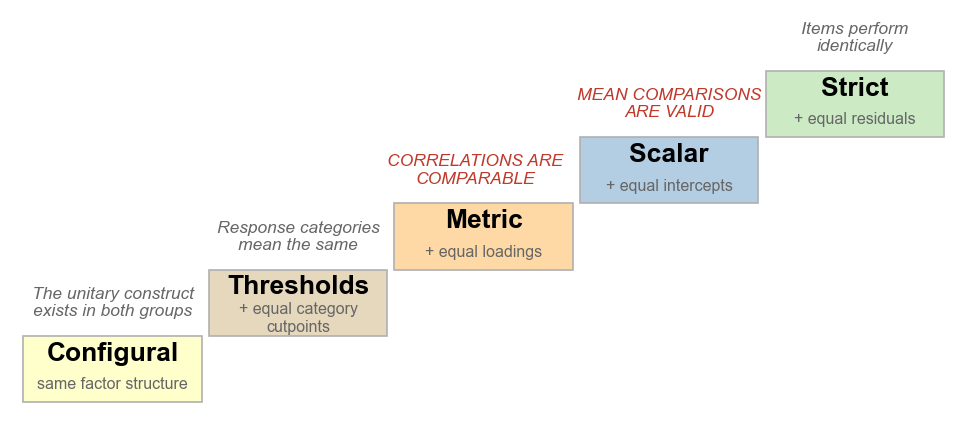

In [42]:
LEVELS = [
    ('Configural', 'same factor structure', 'The unitary construct\nexists in both groups'),
    ('Thresholds', '+ equal category\ncutpoints', 'Response categories\nmean the same'),
    ('Metric', '+ equal loadings', 'CORRELATIONS ARE\nCOMPARABLE'),
    ('Scalar', '+ equal intercepts', 'MEAN COMPARISONS\nARE VALID'),
    ('Strict', '+ equal residuals', 'Items perform\nidentically'),
]
# box fills match the heatmap's level colors
fig, ax = plt.subplots(figsize=(12.2, 5.4))
ax.set_xlim(0, 10.6); ax.set_ylim(0, 6.4)
ax.axis('off')
w, h = 2.0, 1.02
for i, (name, adds, licence) in enumerate(LEVELS):
    x, y = 0.15 + i * 2.08, 0.35 + i * 1.02
    ax.add_patch(Rectangle((x, y), w, h,
                           facecolor=LEVEL_COLORS[name.lower()],
                           edgecolor=LIGHT, lw=1.2))
    ax.text(x + w / 2, y + h - 0.26, name, ha='center', va='center',
            fontsize=19, color=BLACK, weight='bold')
    ax.text(x + w / 2, y + 0.28, adds, ha='center', va='center',
            fontsize=11.5, color=GREY)
    lx = x + w / 2 - (0.1 if name == 'Scalar' else 0)
    lx = x + w / 2 - (0.1 if name == 'Metric' else 0)
    ax.text(lx, y + h + 0.52, licence, ha='center', va='center',
            fontsize=12.5, color=(ACCENT if (name == 'Scalar') | (name == 'Metric') else GREY),
            style='italic')
save(fig, 'fig1_invariance_ladder.png')
plt.show()

## Figure 2 (conceptual): what a violation looks like

Item response curves (probability of endorsing an item as latent severity
increases) for two groups: invariant, a metric (loading) violation, and a
scalar/threshold (calibration) violation — the kind insomnia shows.

saved ../figures/talk/fig2_violation_types.png


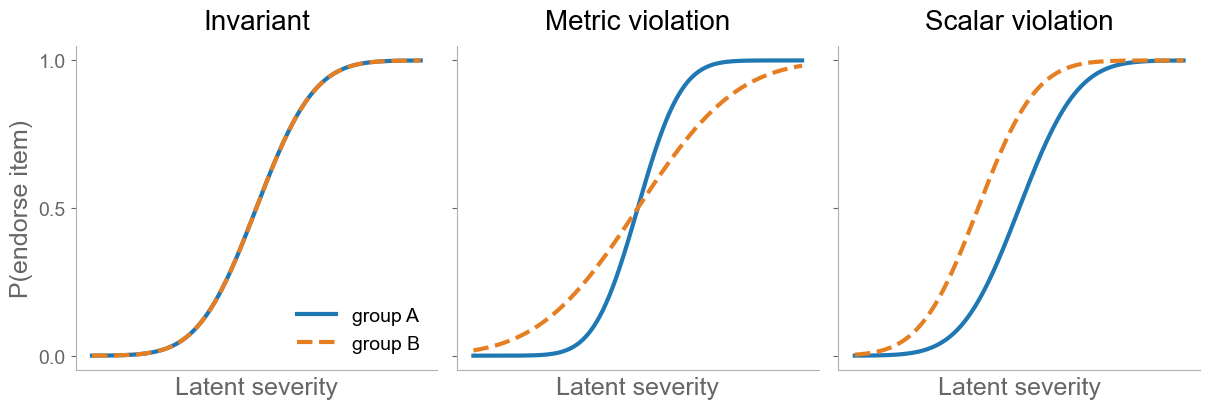

In [30]:
t = np.linspace(-3, 3, 300)
panels = [
    ('Invariant', (1.2, 0.0), (1.2, 0.0)),
    ('Metric violation', (1.6, 0.0), (0.7, 0.0)),
    ('Scalar violation', (1.2, 0.0), (1.2, 0.9)),
]
fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.2), sharey=True)
for ax, (title, (a1, b1), (a2, b2)) in zip(axes, panels):
    ax.plot(t, stats.norm.cdf(a1 * t + b1), color=VAL_C, lw=3,
            label='group A')
    ax.plot(t, stats.norm.cdf(a2 * t + b2), color=EN_C, lw=3,
            ls='--', label='group B')
    ax.set_title(title, fontsize=20, pad=12)
    ax.set_xlabel('Latent severity')
    ax.set_xticks([]); ax.set_yticks([0, 0.5, 1])
axes[0].set_ylabel('P(endorse item)')

axes[0].legend(loc='lower right', frameon=False)
fig.tight_layout()
save(fig, 'fig2_violation_types.png')
plt.show()

## Figure 3 (data): insomnia climbs the ladder, then falls at scalar

Permutation p-values (1000 permutations) per level for VAL vs EN, from
`data/cfa/orig_cfa_res.csv` (generated in `NB_2_cfa_as_reg.ipynb`).

saved ../figures/talk/fig3_insomnia_ladder.png


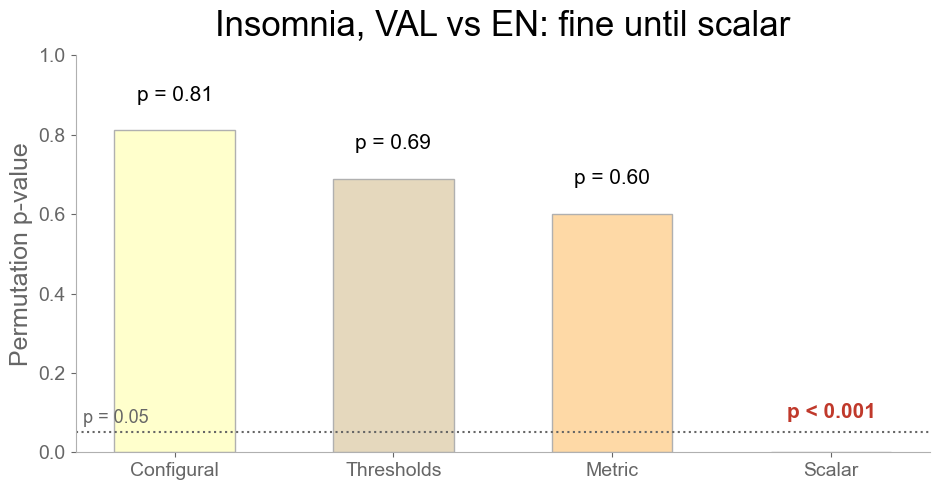

In [44]:
res = pd.read_csv('../data/cfa/orig_cfa_res.csv')
row = res[(res.scale == 'insomnia') & (res.pair == 'V_EN')].iloc[0]
levels = ['Configural', 'Thresholds', 'Metric', 'Scalar']
ps = [row.pconfig, row.pthresholds, row.pmetric, row.pscalar]
colors = [LEVEL_COLORS[k] for k in
          ('configural', 'thresholds', 'metric', 'scalar')]
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(levels, ps, color=colors, width=0.55,
              edgecolor=LIGHT, lw=1)
ax.axhline(0.05, color=GREY, lw=1.5, ls=':')
ax.text(-0.42, 0.075, 'p = 0.05', color=GREY, fontsize=13)
for b, p in zip(bars, ps):
    label = 'p < 0.001' if p < .001 else f'p = {p:.2f}'
    ax.text(b.get_x() + b.get_width() / 2, max(p, 0.012) + 0.075,
            label, ha='center', fontsize=15,
            color=(ACCENT if p < .05 else BLACK),
            weight='bold' if p < .05 else 'normal')
ax.set_ylabel('Permutation p-value')
ax.set_ylim(0, 1.0)
ax.set_title('Insomnia, VAL vs EN: fine until scalar', pad=14)
fig.tight_layout()
save(fig, 'fig3_insomnia_ladder.png')
plt.show()

## Figures 4–5 (data): where the failure lives, and what it costs

Refit the VAL–EN metric model via `hitop_cfa.dif_effect_sizes` (which leaves
`fit_metric_es` in the R session), extract loadings/thresholds/free EN
intercepts, and draw each item's expected-score curve for the two groups at
**matched latent severity** (the severity shift α removed, so any visible gap
is pure DIF). Then the decomposition: the real severity gap vs the
measurement bias, on the 12-point sum scale.

In [24]:
from hitop_cfa import dif_effect_sizes
from hitop_cfa.r_env import localconverter, pandas2ri, ro

fin = Path('../data/finaldata')
data_val = pd.read_csv(fin / 'dat_val.csv')
data_en = pd.read_csv(fin / 'dat_en_grid1st_full.csv')
pair = pd.concat([data_val, data_en])   # val first = reference group

per_item, summ = dif_effect_sizes('insomnia', ITEMS, pair,
                                  fig_dir / 'talk_temp.csv')
print('groups:', summ['group_labels'], ' alpha =', round(summ['alpha'], 3))
print(per_item[['item', 'd', 'd_lo', 'd_hi', 'dMACS']].round(3)
      .to_string(index=False))

with localconverter(ro.default_converter + pandas2ri.converter):
    pt = ro.conversion.rpy2py(ro.r('lavaan::parameterTable(fit_metric_es)'))
theta = np.asarray(ro.r('lavaan::coef(fit_metric_es)'))
def par(rows):
    return theta[(rows.free.values - 1).astype(int)]
lam = {i: float(par(pt[(pt.op == '=~') & (pt.rhs == i)
                       & (pt.group == 1)])[0]) for i in ITEMS}
tau = {i: par(pt[(pt.op == '|') & (pt.lhs == i)
                 & (pt.group == 1)].sort_values('rhs')) for i in ITEMS}
dif = dict(zip(per_item.item, per_item.d))

groups: ['validation', 'enriched']  alpha = 0.26
    item      d   d_lo   d_hi  dMACS
hitop160 -0.040 -0.231  0.151  0.018
hitop254  0.182  0.006  0.385  0.086
hitop261 -0.339 -0.538 -0.161  0.229
hitop268  0.132 -0.031  0.324  0.086


saved ../figures/talk/fig4_item_curves.png


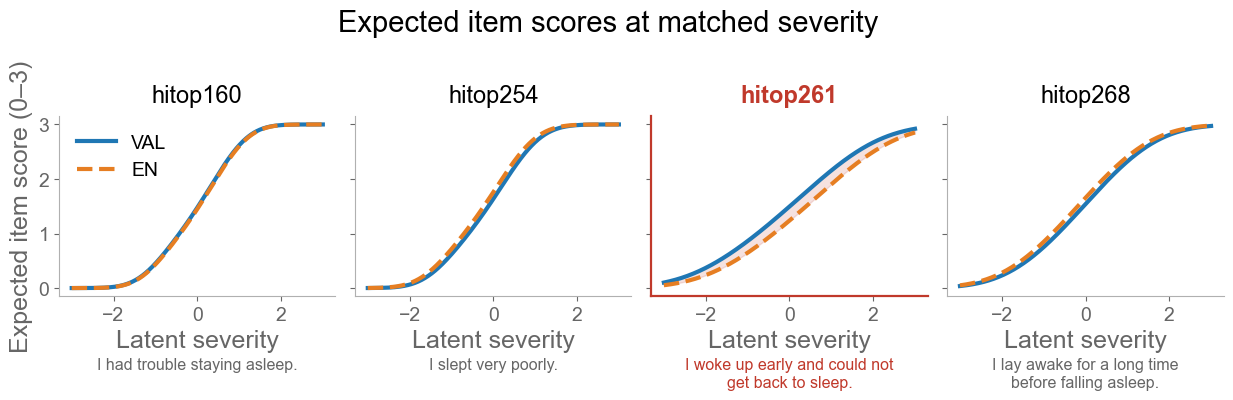

In [43]:
tt = np.linspace(-3, 3, 300)
fig, axes = plt.subplots(1, 4, figsize=(12.6, 4.3), sharey=True)
for ax, item in zip(axes, ITEMS):
    e_val = stats.norm.cdf(lam[item] * tt[:, None]
                           - tau[item][None, :]).sum(axis=1)
    e_en = stats.norm.cdf(lam[item] * tt[:, None] + dif[item]
                          - tau[item][None, :]).sum(axis=1)
    ax.plot(tt, e_val, color=VAL_C, lw=3, label='VAL')
    ax.plot(tt, e_en, color=EN_C, lw=3, ls='--', label='EN')
    is_dif = item == 'hitop261'
    ax.set_title(item, fontsize=17, color=(ACCENT if is_dif else BLACK),
                 pad=10, weight='bold' if is_dif else 'normal')
    ax.text(0.5, -0.34, ITEM_TEXT[item].replace('\\n', '\n'),
            transform=ax.transAxes, ha='center', va='top', fontsize=11.5,
            color=(ACCENT if is_dif else GREY))
    if is_dif:
        for spine in ax.spines.values():
            spine.set_edgecolor(ACCENT); spine.set_linewidth(1.6)
        ax.fill_between(tt, e_val, e_en, color=ACCENT, alpha=0.15)
    ax.set_xlabel('Latent severity')
axes[0].set_ylabel('Expected item score (0\u20133)')
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Expected item scores at '
             'matched severity', fontsize=21, color=BLACK, y=1.04)
fig.tight_layout()
save(fig, 'fig4_item_curves.png')
plt.show()

saved ../figures/talk/fig5_bias_decomposition.png


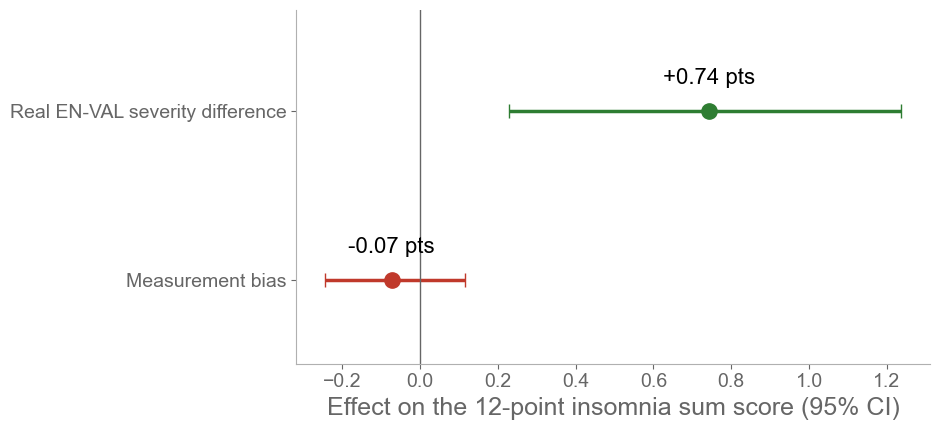

In [32]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
vals = [summ['real_gap_points'], summ['net_sum_bias_points']]
cis = [summ['real_gap_ci'], summ['net_ci']]
labels = ['Real EN-VAL severity difference',
          'Measurement bias']
y = [1, 0]
for yi, v, (lo, hi), c in zip(y, vals, cis, ['#2e7d32', ACCENT]):
    ax.errorbar(v, yi, xerr=[[v - lo], [hi - v]], fmt='o', ms=11,
                color=c, capsize=5, lw=2.5)
    ax.text(v, yi + 0.16, f'{v:+.2f} pts', ha='center', fontsize=16,
            color=BLACK)
ax.axvline(0, color=GREY, lw=1)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=14)
ax.set_ylim(-0.5, 1.6)
ax.set_xlabel('Effect on the 12-point insomnia sum score (95% CI)')
fig.tight_layout()
save(fig, 'fig5_bias_decomposition.png')
plt.show()

## Figure 6 (data): the repair

Drop hitop261 → the 3-item core {160, 254, 268} is scalar-invariant across
all three samples (stepwise result confirmed by the exhaustive search as the
only invariant subset; `NB_2_cfa_as_reg.ipynb` / `NB_2_cfa_exploratory.ipynb`),
with no loss of reliability (`NB_3_ICC.ipynb`) or validity
(`NB_core_effects.ipynb`, hypothesis C6).

saved ../figures/talk/fig6_core_repair.png


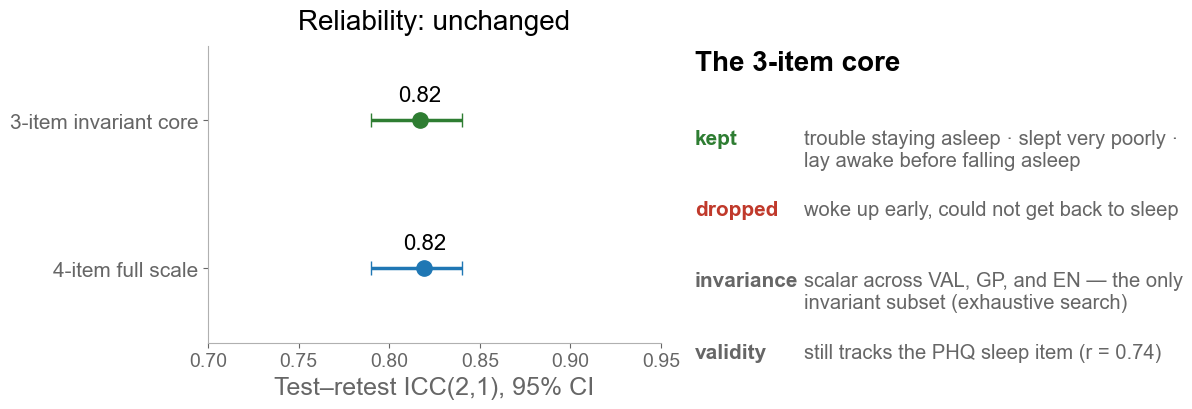

In [20]:
icc_fs = pd.read_csv('../data/icc/result_ICC_origscales_combined.csv')
icc_ic = pd.read_csv('../data/icc/result_ICC_invariantonly_combined.csv')
fs = icc_fs[icc_fs.Measure == 'hitop_insomnia'].iloc[0]
ic = icc_ic[icc_ic.Measure == 'hitop_insomnia__invcore'].iloc[0]
cd = pd.read_csv('../data/core_effects/convdiv_gp_en.csv')
c6 = cd[cd.hypothesis == 'C6'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2),
                         gridspec_kw={'width_ratios': [1, 1]})
ax = axes[0]
for yi, (label, r) in enumerate([('4-item full scale', fs),
                                 ('3-item invariant core', ic)]):
    ax.errorbar(r.ICC, yi, xerr=[[r.ICC - r.lci], [r.uci - r.ICC]],
                fmt='o', ms=11, capsize=5, lw=2.5,
                color=[VAL_C, '#2e7d32'][yi])
    ax.text(r.ICC, yi + 0.13, f'{r.ICC:.2f}', ha='center', fontsize=16,
            color=BLACK)
ax.set_yticks([0, 1])
ax.set_yticklabels(['4-item full scale', '3-item invariant core'],
                   fontsize=15)
ax.set_ylim(-0.5, 1.5); ax.set_xlim(0.7, 0.95)
ax.set_xlabel('Test\u2013retest ICC(2,1), 95% CI')
ax.set_title('Reliability: unchanged', fontsize=20, pad=12)

ax = axes[1]
ax.axis('off')
ax.text(0.0, 0.92, 'The 3-item core', fontsize=20, color=BLACK,
        weight='bold')
lines = [
    ('kept', 'trouble staying asleep \u00b7 slept very poorly \u00b7\n'
             'lay awake before falling asleep', '#2e7d32'),
    ('dropped', 'woke up early, could not get back to sleep', ACCENT),
    ('invariance', 'scalar across VAL, GP, and EN \u2014 the only\n'
                   'invariant subset (exhaustive search)', GREY),
    ('validity', f'still tracks the PHQ sleep item '
                 f'(r = {c6.statistic:.2f})', GREY),
]
yy = 0.72
for tag, txt, c in lines:
    ax.text(0.0, yy, tag, fontsize=15, color=c, weight='bold', va='top')
    ax.text(0.24, yy, txt, fontsize=14.5, color=GREY, va='top')
    yy -= 0.24
fig.tight_layout()
save(fig, 'fig6_core_repair.png')
plt.show()

## Figure 7 (conceptual): the SEM, and what each level constrains

Two-group one-factor CFA of insomnia (VAL and EN fitted simultaneously).
Each parameter class is badged with the color of the invariance level that
forces it to be equal across groups — colors identical to the results
heatmap (`figures/invariance_ladder_heatmap.png`).

saved ../figures/talk/fig7_sem_constraints.png


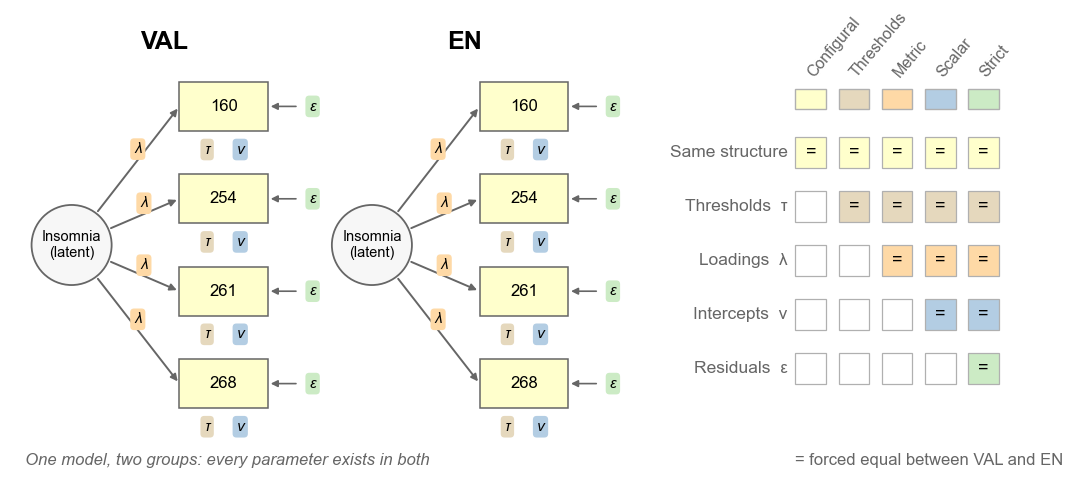

In [39]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(13.4, 6.0))
ax.set_xlim(0, 132); ax.set_ylim(-4, 56)
ax.set_aspect('equal'); ax.axis('off')

def badge(x, y, sym, level, fs=11):
    ax.text(x, y, sym, ha='center', va='center', fontsize=fs, color=BLACK,
            style='italic',
            bbox=dict(boxstyle='round,pad=0.25',
                      fc=LEVEL_COLORS[level], ec='none'))

ITEM_NOS = ['160', '254', '261', '268']
for xo, gname in ((1, 'VAL'), (40, 'EN')):
    ax.text(xo + 19, 51.5, gname, ha='center', fontsize=18, color=BLACK,
            weight='bold')
    ax.add_patch(Circle((xo + 7, 26), 5.2, facecolor='#f7f7f7',
                        edgecolor=GREY, lw=1.3))
    ax.text(xo + 7, 26, 'Insomnia\n(latent)', ha='center', va='center',
            fontsize=10.5, color=BLACK)
    for yc, ino in zip([44, 32, 20, 8], ITEM_NOS):
        # structure itself = the configural level
        ax.add_patch(Rectangle((xo + 21, yc - 3.2), 11.5, 6.4,
                               facecolor=LEVEL_COLORS['configural'],
                               edgecolor=GREY, lw=1.1))
        ax.text(xo + 26.75, yc, ino, ha='center', va='center', fontsize=12,
                color=BLACK)
        # loading arrow + lambda badge (metric)
        cx, cy = xo + 7, 26
        dx, dy = (xo + 21) - cx, yc - cy
        norm = (dx ** 2 + dy ** 2) ** 0.5
        sx, sy = cx + 5.2 * dx / norm, cy + 5.2 * dy / norm
        ax.annotate('', xy=(xo + 21, yc), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='-|>', color=GREY, lw=1.4))
        badge((sx + xo + 21) / 2, (sy + yc) / 2 + 1.4, 'λ', 'metric')
        # thresholds tau + intercept nu under each indicator
        badge(xo + 24.6, yc - 5.6, 'τ', 'thresholds')
        badge(xo + 28.9, yc - 5.6, 'ν', 'scalar')
        # residual arrow + epsilon badge (strict)
        ax.annotate('', xy=(xo + 32.5, yc), xytext=(xo + 36.5, yc),
                    arrowprops=dict(arrowstyle='-|>', color=GREY, lw=1.2))
        badge(xo + 38.3, yc, 'ε', 'strict')

# constraint grid
LEV = [('Configural', 'configural'), ('Thresholds', 'thresholds'),
       ('Metric', 'metric'), ('Scalar', 'scalar'), ('Strict', 'strict')]
ROWS = [('Same structure', 'configural', 0),
        ('Thresholds  τ', 'thresholds', 1),
        ('Loadings  λ', 'metric', 2),
        ('Intercepts  ν', 'scalar', 3),
        ('Residuals  ε', 'strict', 4)]
gx = [104 + i * 5.6 for i in range(5)]
for (lname, lkey), xc in zip(LEV, gx):
    ax.add_patch(Rectangle((xc - 2.0, 43.6), 4.0, 2.6,
                           facecolor=LEVEL_COLORS[lkey], edgecolor=LIGHT))
    ax.text(xc - 0.8, 47.4, lname, rotation=50, ha='left', va='bottom',
            fontsize=11.5, color=GREY)
for rname, rkey, start in ROWS:
    yr = 38 - ROWS.index((rname, rkey, start)) * 7
    ax.text(101.0, yr, rname, ha='right', va='center', fontsize=12.5,
            color=GREY)
    for i, xc in enumerate(gx):
        on = i >= start
        ax.add_patch(Rectangle((xc - 2.0, yr - 2.0), 4.0, 4.0,
                               facecolor=(LEVEL_COLORS[rkey] if on
                                          else 'white'),
                               edgecolor=LIGHT, lw=0.9))
        if on:
            ax.text(xc, yr, '=', ha='center', va='center', fontsize=13,
                    color=BLACK)
ax.text(102, -2.5, '= forced equal between VAL and EN',
        fontsize=12, color=GREY)
ax.text(2, -2.5, 'One model, two groups: every parameter exists in both',
        fontsize=12, color=GREY, style='italic')
save(fig, 'fig7_sem_constraints.png')
plt.show()

## Figure 8 (data): DIF-induced sum-score bias, all sample-pair violations

Talk-formatted version of the forest in `NB_invariance_effect_sizes.ipynb`,
restricted to the three sample pairs (VAL-GP, VAL-EN, GP-EN; wave
comparisons omitted). Net bias as % of each scale's range with 95% CIs;
insomnia highlighted; the single CI excluding zero starred.

saved ../figures/talk/fig8_dif_bias_pairs.png


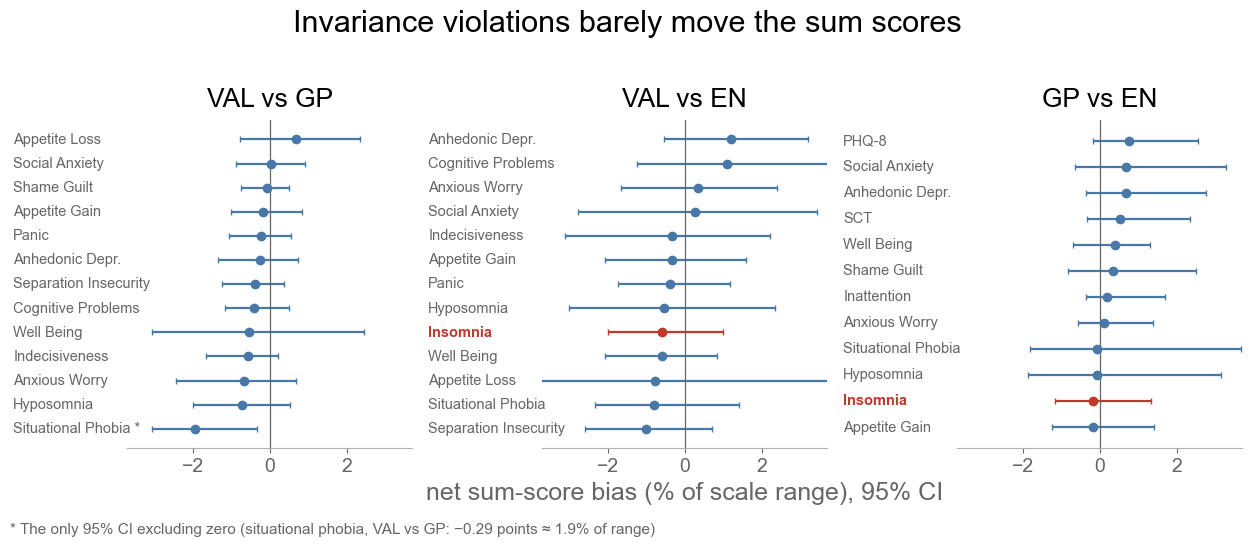

In [19]:
s = pd.read_csv('../data/effect_sizes/pairwise_dif_summary.csv')
s = s[s.error.isna() & s.pair.isin(['val_gp', 'val_en', 'gp_en'])].copy()
s['net_pct'] = s.net_bias_pts / s.scale_max * 100
s['lo_pct'] = s.net_lo / s.scale_max * 100
s['hi_pct'] = s.net_hi / s.scale_max * 100

NICE = {'phq_sum': 'PHQ-8', 'baars_sct_sum': 'SCT',
        'baars_inattention_sum': 'Inattention',
        'anhedonic_depression': 'Anhedonic Depr.'}
def nice(sc):
    return NICE.get(sc, sc.replace('_', ' ').title())

PAIRS = [('val_gp', 'VAL vs GP'), ('val_en', 'VAL vs EN'),
         ('gp_en', 'GP vs EN')]
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.9), sharex=True)
for ax, (pair, title) in zip(axes, PAIRS):
    sub = s[s.pair == pair].sort_values('net_pct').reset_index(drop=True)
    for j, r in enumerate(sub.itertuples()):
        hot = r.scale == 'insomnia'
        star = (r.net_lo > 0) or (r.net_hi < 0)
        c = ACCENT if hot else '#4878a8'
        ax.errorbar(r.net_pct, j, xerr=[[r.net_pct - r.lo_pct],
                                        [r.hi_pct - r.net_pct]],
                    fmt='o', ms=6, capsize=2.5, lw=1.6, color=c)
        ax.text(-0.4, j, nice(r.scale) + (' *' if star else ''),
                transform=ax.get_yaxis_transform(), ha='left', va='center',
                fontsize=10.5, color=(ACCENT if hot else GREY),
                weight='bold' if hot else 'normal')
    ax.axvline(0, color=GREY, lw=0.9)
    ax.set_yticks([])
    ax.set_ylim(-0.8, len(sub) - 0.2)
    ax.set_title(title, fontsize=19, pad=10)
    ax.spines['left'].set_visible(False)
axes[1].set_xlabel('net sum-score bias (% of scale range), 95% CI')
axes[0].set_xlim(-3.7, 3.7)
fig.suptitle('Invariance violations barely move the sum scores',
             fontsize=22, color=BLACK, y=1.04)
fig.text(0.01, -0.03, '* The only 95% CI excluding zero '
         '(situational phobia, VAL vs GP: −0.29 points ≈ 1.9% '
         'of range)', fontsize=11, color=GREY)
fig.tight_layout()
save(fig, 'fig8_dif_bias_pairs.png')
plt.show()

## Figure 9 (conceptual): the measurement model the parameters live in

The ordinal factor model behind fig7, with each parameter badged in its
invariance-level color (same scheme as the heatmap): latent response,
categorization through thresholds, and the group distributions that stay
free.

saved ../figures/talk/fig9_model_equation_no_hilights.png


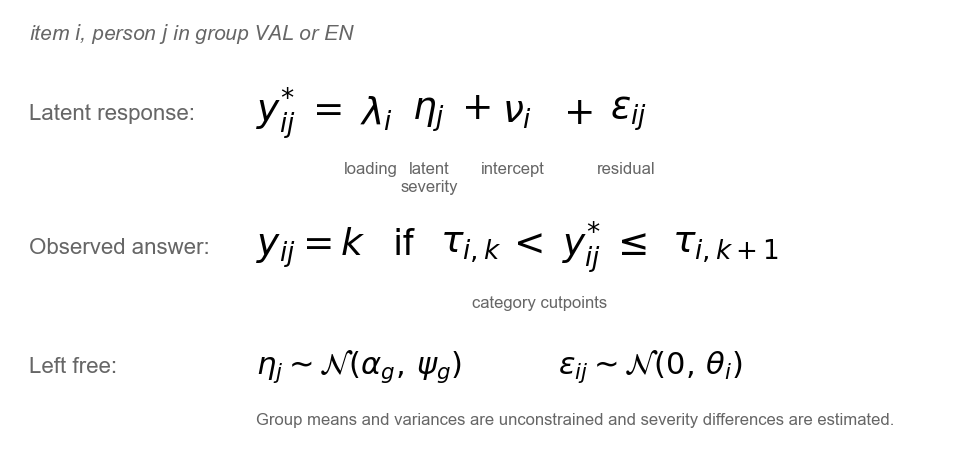

In [40]:
fig, ax = plt.subplots(figsize=(12.2, 5.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 58)
ax.axis('off')

def eq(x, y, s, fs=27, color=BLACK, level=None, ha='left'):
    kw = {}
    if level:
        kw['bbox'] = dict(boxstyle='round,pad=0.32',
                          fc=LEVEL_COLORS[level], ec='none')
    ax.text(x, y, s, fontsize=fs, color=color, ha=ha, va='center', **kw)

ax.text(2, 54, 'item $i$, person $j$ in group VAL or EN', fontsize=15,
        color=GREY, style='italic')

# latent response
Y1 = 44
eq(2, Y1, 'Latent response:', 16, GREY)
eq(26, Y1, r'$y^{*}_{ij}\;=$')
eq(37, Y1, r'$\lambda_i$')
eq(42.5, Y1, r'$\eta_j\;+$')
eq(52, Y1, r'$\nu_i$')
eq(58.5, Y1, '$+$')
eq(63.5, Y1, r'$\varepsilon_{ij}$')
for x, lab in ((38.2, 'loading'), (44.3, 'latent\nseverity'),
               (53.2, 'intercept'), (65.2, 'residual')):
    ax.text(x, Y1 - 6.5, lab, fontsize=12, color=GREY, ha='center',
            va='top')

# categorization
Y2 = 26
eq(2, Y2, 'Observed answer:', 16, GREY)
eq(26, Y2, r'$y_{ij}=k$   if')
eq(45.5, Y2, r'$\tau_{i,k}$')
eq(52.5, Y2, r'$<\;y^{*}_{ij}\;\leq$')
eq(70, Y2, r'$\tau_{i,k+1}$')
ax.text(56, Y2 - 6.5, 'category cutpoints', fontsize=12, color=GREY,
        ha='center', va='top')

# distributions
Y3 = 10
eq(2, Y3, 'Left free:', 16, GREY)
eq(26, Y3, r'$\eta_j \sim \mathcal{N}(\alpha_g,\,\psi_g)$', 22)
eq(58, Y3, r'$\varepsilon_{ij} \sim \mathcal{N}(0,\,\theta_i)$', 22)
ax.text(26, Y3 - 6.2,
        'Group means and variances are unconstrained and '
        'severity differences are estimated.',
        fontsize=12, color=GREY, va='top')


save(fig, 'fig9_model_equation_no_hilights.png')
plt.show()

saved ../figures/talk/fig9_model_equation.png


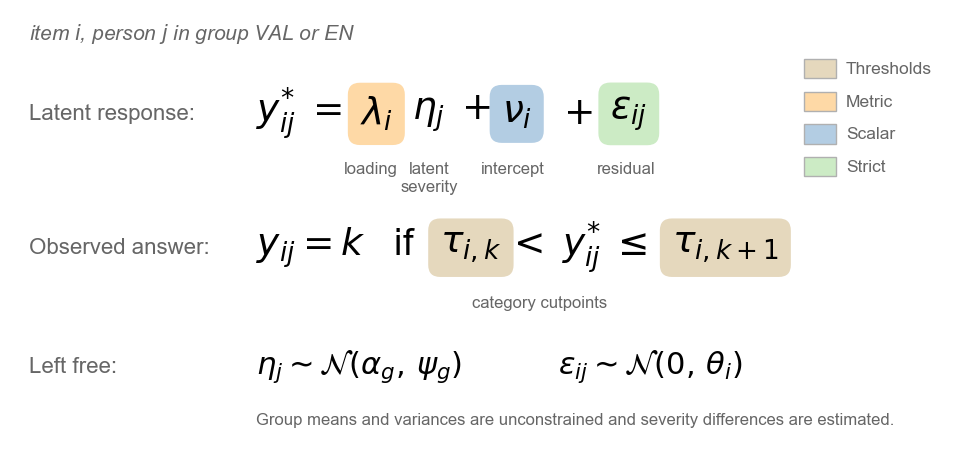

In [41]:
fig, ax = plt.subplots(figsize=(12.2, 5.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 58)
ax.axis('off')

def eq(x, y, s, fs=27, color=BLACK, level=None, ha='left'):
    kw = {}
    if level:
        kw['bbox'] = dict(boxstyle='round,pad=0.32',
                          fc=LEVEL_COLORS[level], ec='none')
    ax.text(x, y, s, fontsize=fs, color=color, ha=ha, va='center', **kw)

ax.text(2, 54, 'item $i$, person $j$ in group VAL or EN', fontsize=15,
        color=GREY, style='italic')

# latent response
Y1 = 44
eq(2, Y1, 'Latent response:', 16, GREY)
eq(26, Y1, r'$y^{*}_{ij}\;=$')
eq(37, Y1, r'$\lambda_i$', level='metric')
eq(42.5, Y1, r'$\eta_j\;+$')
eq(52, Y1, r'$\nu_i$', level='scalar')
eq(58.5, Y1, '$+$')
eq(63.5, Y1, r'$\varepsilon_{ij}$', level='strict')
for x, lab in ((38.2, 'loading'), (44.3, 'latent\nseverity'),
               (53.2, 'intercept'), (65.2, 'residual')):
    ax.text(x, Y1 - 6.5, lab, fontsize=12, color=GREY, ha='center',
            va='top')

# categorization
Y2 = 26
eq(2, Y2, 'Observed answer:', 16, GREY)
eq(26, Y2, r'$y_{ij}=k$   if')
eq(45.5, Y2, r'$\tau_{i,k}$', level='thresholds')
eq(52.5, Y2, r'$<\;y^{*}_{ij}\;\leq$')
eq(70, Y2, r'$\tau_{i,k+1}$', level='thresholds')
ax.text(56, Y2 - 6.5, 'category cutpoints', fontsize=12, color=GREY,
        ha='center', va='top')

# distributions
Y3 = 10
eq(2, Y3, 'Left free:', 16, GREY)
eq(26, Y3, r'$\eta_j \sim \mathcal{N}(\alpha_g,\,\psi_g)$', 22)
eq(58, Y3, r'$\varepsilon_{ij} \sim \mathcal{N}(0,\,\theta_i)$', 22)
ax.text(26, Y3 - 6.2,
        'Group means and variances are unconstrained and '
        'severity differences are estimated.',
        fontsize=12, color=GREY, va='top')

# level legend
ly = 50
for lname, lkey in [('Thresholds', 'thresholds'), ('Metric', 'metric'),
                    ('Scalar', 'scalar'), ('Strict', 'strict')]:
    ax.add_patch(Rectangle((84, ly - 1.2), 3.4, 2.6,
                           facecolor=LEVEL_COLORS[lkey], edgecolor=LIGHT))
    ax.text(88.4, ly, lname, fontsize=12.5, color=GREY, va='center')
    ly -= 4.4
save(fig, 'fig9_model_equation.png')
plt.show()